# Model LSTM – Predicció de Generació Renovable
**TFG – Gestió de Ciutats Intel·ligents i Sostenibles**  
**Arnau Ropero Garcia | UAB | Curs 2025–26**

Aquest notebook implementa el model **LSTM** (Long Short-Term Memory) per predir la generació solar i eòlica a Espanya.

## Diferències respecte a Prophet i XGBoost

| | Prophet | XGBoost | LSTM |
|---|---|---|---|
| Veu les dades com | Tendència + estacionalitat | Files independents | Seqüència temporal |
| Memòria temporal | Implícita | Lags manuals | Apresa automàticament |
| Lags necessaris | No | Sí (manuals) | No (la finestra és la memòria) |
| Complexitat | Baixa | Mitjana | Alta |

## Escenari de predicció
El LSTM rep una **finestra de les últimes W hores** (features meteorològiques + generació passada)
i prediu la generació de **la hora següent** (one-step-ahead).
Igual que XGBoost, és un escenari de predicció amb observació contínua.

## Splits
- **Entrenament:** 2023–2024
- **Validació:** Gener–Març 2025 (també usada per early stopping)
- **Test:** Abril–Maig 2025 (inclou apagada 28 abril)

## 0. Instal·lació de dependències

In [ ]:
# Executar només si cal
#%pip install tensorflow scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow


## 1. Importacions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Reproductibilitat
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print(f'TensorFlow versió: {tf.__version__}')
print('Llibreries carregades correctament.')

TensorFlow versió: 2.21.0
Llibreries carregades correctament.


## 2. Càrrega del dataset

In [3]:
PATH = r'C:\Users\Arnau\Universitat\Grau de gestió de ciutats intel·ligents i sostenibles\4rt curs\TFG\dades\dataset_final_2023-2025.csv'

df = pd.read_csv(PATH, parse_dates=['timestamp_utc'], index_col='timestamp_utc')
df.index = pd.to_datetime(df.index, utc=True).tz_convert('Europe/Madrid')

print(f'Shape: {df.shape}')
print(f'Rang temporal: {df.index.min()} → {df.index.max()}')

Shape: (21000, 25)
Rang temporal: 2023-01-08 00:00:00+01:00 → 2025-05-31 23:00:00+02:00


## 3. Definició de features i hiperparàmetres

**Nota sobre els lags:** El LSTM NO necessita lags manuals com XGBoost.
La finestra temporal (WINDOW_SIZE) fa la mateixa funció: el model rep les últimes
W hores i aprèn automàticament quina informació passada és rellevant.

In [4]:
# --- Features ---
# IMPORTANT: NO usem els lags (lag1h, lag24h, lag168h) perquè la finestra temporal
# ja proporciona aquesta informació de forma implícita.

FEATURES_SOLAR = [
    'shortwave_radiation_Wm2',
    'direct_radiation_Wm2',
    'diffuse_radiation_Wm2',
    'cloud_cover_pct',
    'temperature_2m_C',
    'hora',
    'dia_setmana',
    'mes',
    'dia_any',
    'is_cap_de_setmana',
    'is_festiu',
    'solar_MW',   # target inclòs com a feature (valor passat a la finestra)
]

FEATURES_EOLIC = [
    'wind_speed_100m_ms',
    'wind_speed_10m_ms',
    'wind_gusts_10m_ms',
    'temperature_2m_C',
    'precipitation_mm',
    'hora',
    'dia_setmana',
    'mes',
    'dia_any',
    'is_cap_de_setmana',
    'is_festiu',
    'eolic_MW',   # target inclòs com a feature (valor passat a la finestra)
]

TARGET_SOLAR = 'solar_MW'
TARGET_EOLIC = 'eolic_MW'

# --- Hiperparàmetres ---
WINDOW_SIZE  = 24    # hores de context que rep el model (= 1 dia)
BATCH_SIZE   = 64
EPOCHS       = 50
LSTM_UNITS   = 64   # neurones a la capa LSTM
DROPOUT      = 0.2  # regularització per evitar overfitting
PATIENCE     = 10   # early stopping: atura si no millora en 10 èpoques

print(f'Finestra temporal: {WINDOW_SIZE}h')
print(f'Features solar: {len(FEATURES_SOLAR)} | Features eòlica: {len(FEATURES_EOLIC)}')

Finestra temporal: 24h
Features solar: 12 | Features eòlica: 12


## 4. Funcions auxiliars

In [5]:
def calcular_metriques(y_true, y_pred, nom=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    if nom:
        print(f'--- {nom} ---')
    print(f'  MAE : {mae:,.1f} MW')
    print(f'  RMSE: {rmse:,.1f} MW')
    print(f'  MAPE: {mape:.2f} %')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


def crear_sequences(X, y, window_size):
    """
    Transforma les dades tabulars en seqüències per al LSTM.
    
    Per cada hora t, crea una seqüència de les últimes `window_size` hores
    com a entrada, i el valor de l'hora t com a target.
    
    Input shape:  (N, n_features)
    Output shape: X_seq=(N-W, W, n_features), y_seq=(N-W,)
    """
    X_seq, y_seq = [], []
    for i in range(window_size, len(X)):
        X_seq.append(X[i - window_size:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)


def plot_prediccions(dates, y_true, y_pred, titol, y_label='MW',
                     highlight_start=None, highlight_end=None):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, y_true, label='Real', color='steelblue', linewidth=1)
    ax.plot(dates, y_pred, label='Predicció LSTM', color='mediumseagreen',
            linewidth=1, linestyle='--')
    if highlight_start and highlight_end:
        ax.axvspan(pd.Timestamp(highlight_start), pd.Timestamp(highlight_end),
                   alpha=0.15, color='orange', label='Apagada 28 abr')
    ax.set_title(titol, fontweight='bold')
    ax.set_ylabel(y_label)
    ax.set_xlabel('Data')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


def plot_training(history, titol):
    """Gràfic de la corba d'aprenentatge (loss train vs val)."""
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history.history['loss'],     label='Train loss', color='steelblue')
    ax.plot(history.history['val_loss'], label='Val loss',   color='tomato')
    ax.set_title(titol, fontweight='bold')
    ax.set_xlabel('Època')
    ax.set_ylabel('MSE (escala normalitzada)')
    ax.legend()
    plt.tight_layout()
    plt.show()


print('Funcions auxiliars definides.')

Funcions auxiliars definides.


## 5. Divisió temporal

In [6]:
train = df[df['split'] == 'train'].copy()
val   = df[df['split'] == 'validation'].copy()
test  = df[df['split'] == 'test'].copy()

print(f'Train: {train.index.min().date()} → {train.index.max().date()}  ({len(train):,} registres)')
print(f'Val:   {val.index.min().date()} → {val.index.max().date()}  ({len(val):,} registres)')
print(f'Test:  {test.index.min().date()} → {test.index.max().date()}  ({len(test):,} registres)')

Train: 2023-01-08 → 2025-01-01  (17,377 registres)
Val:   2025-01-01 → 2025-04-01  (2,161 registres)
Test:  2025-04-01 → 2025-05-31  (1,462 registres)


---
## 6. MODEL A: Solar PV
### 6.1 Normalització

El LSTM és sensible a l'escala de les dades — cal normalitzar.
**Regla fonamental:** el scaler s'entrena NOMÉS amb el train, i s'aplica a val i test.
Fer-ho al revés seria data leakage.

In [7]:
scaler_solar = MinMaxScaler()

# Fit NOMÉS amb train
X_train_solar_raw = train[FEATURES_SOLAR].values
X_val_solar_raw   = val[FEATURES_SOLAR].values
X_test_solar_raw  = test[FEATURES_SOLAR].values

X_train_solar_norm = scaler_solar.fit_transform(X_train_solar_raw)
X_val_solar_norm   = scaler_solar.transform(X_val_solar_raw)
X_test_solar_norm  = scaler_solar.transform(X_test_solar_raw)

# Index de la columna target dins de FEATURES_SOLAR (per desnormalitzar)
idx_target_solar = FEATURES_SOLAR.index(TARGET_SOLAR)

y_train_solar = train[TARGET_SOLAR].values
y_val_solar   = val[TARGET_SOLAR].values
y_test_solar  = test[TARGET_SOLAR].values

print(f'Scaler entrenat amb {len(X_train_solar_raw):,} registres de train.')
print(f'Index target solar dins features: {idx_target_solar}')

Scaler entrenat amb 17,377 registres de train.
Index target solar dins features: 11


### 6.2 Creació de seqüències

Transformem les dades en seqüències de WINDOW_SIZE hores.

**Concatenació train+val per a les seqüències de val:**
La primera seqüència de validació necessita les últimes WINDOW_SIZE hores del train
per tenir context. Per això concatenem train+val abans de crear seqüències.

In [16]:
# Seqüències de train
X_seq_train_solar, y_seq_train_solar = crear_sequences(
    X_train_solar_norm, y_train_solar, WINDOW_SIZE
)

# Seqüències de val: necessitem les últimes W hores del train com a context
X_trainval_solar_norm = np.concatenate([X_train_solar_norm, X_val_solar_norm])
y_trainval_solar      = np.concatenate([y_train_solar, y_val_solar])
X_seq_all_solar, y_seq_all_solar = crear_sequences(
    X_trainval_solar_norm, y_trainval_solar, WINDOW_SIZE
)
X_seq_val_solar = X_seq_all_solar[len(X_seq_train_solar):]
y_seq_val_solar = y_seq_all_solar[len(X_seq_train_solar):]  # ← X, no y

# Seqüències de test: necessitem les últimes W hores del val com a context
X_valtest_solar_norm = np.concatenate([X_val_solar_norm, X_test_solar_norm])
y_valtest_solar      = np.concatenate([y_val_solar, y_test_solar])
X_seq_all_test_solar, y_seq_all_test_solar = crear_sequences(
    X_valtest_solar_norm, y_valtest_solar, WINDOW_SIZE
)
X_seq_test_solar = X_seq_all_test_solar[len(X_seq_val_solar):]
y_seq_test_solar = y_seq_all_test_solar[len(X_seq_val_solar):]  # ← X, no y

print(f'Train sequences: {X_seq_train_solar.shape}')
print(f'Val   sequences: {X_seq_val_solar.shape}')
print(f'Test  sequences: {X_seq_test_solar.shape}')
print(f'Input shape per mostra: (window={WINDOW_SIZE}, features={X_seq_train_solar.shape[2]})')

# El val ha de tenir len(val) - WINDOW_SIZE seqüències
X_seq_val_solar = X_seq_val_solar[:len(val) - WINDOW_SIZE]
y_seq_val_solar = y_seq_val_solar[:len(val) - WINDOW_SIZE]

print(f'Val   sequences (corregit): {X_seq_val_solar.shape}')
print(f'Coincideix amb val.index[WINDOW_SIZE:]: {len(val.index[WINDOW_SIZE:])}')

Train sequences: (17353, 24, 12)
Val   sequences: (2161, 24, 12)
Test  sequences: (1438, 24, 12)
Input shape per mostra: (window=24, features=12)
Val   sequences (corregit): (2137, 24, 12)
Coincideix amb val.index[WINDOW_SIZE:]: 2137


### 6.3 Arquitectura del model

Arquitectura senzilla i eficaç per a sèries temporals univariants/multivariants:
- Capa LSTM amb `return_sequences=False` (només necessitem l'últim pas)
- Dropout per regularització
- Capa densa de sortida (1 neurone = 1 valor predit)

In [17]:
def construir_model(input_shape, lstm_units=64, dropout=0.2):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(lstm_units, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse'
    )
    return model

model_solar = construir_model(
    input_shape=(WINDOW_SIZE, X_seq_train_solar.shape[2]),
    lstm_units=LSTM_UNITS,
    dropout=DROPOUT
)
model_solar.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,825 (85.25 KB)

 Trainable params: 21,825 (85.25 KB)

 Non-trainable params: 0 (0.00 B)

### 6.4 Entrenament amb early stopping

Epoch 1/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 61713568.0000 - val_loss: 43341592.0000
Epoch 2/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 56509508.0000 - val_loss: 38140536.0000
Epoch 3/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 49092956.0000 - val_loss: 33131174.0000
Epoch 4/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 42808932.0000 - val_loss: 30461280.0000
Epoch 5/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 39253224.0000 - val_loss: 30063810.0000
Epoch 6/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 37798024.0000 - val_loss: 29879152.0000
Epoch 7/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 34987540.0000 - val_loss: 17024880.0000
Epoch 8/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 25068818.0000 - val_loss: 28066562.0000
Epoch 9/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 27826984.0000 - val_loss: 14458754.0000
Epoch 10/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 14964171.0000 - val_loss: 8045921

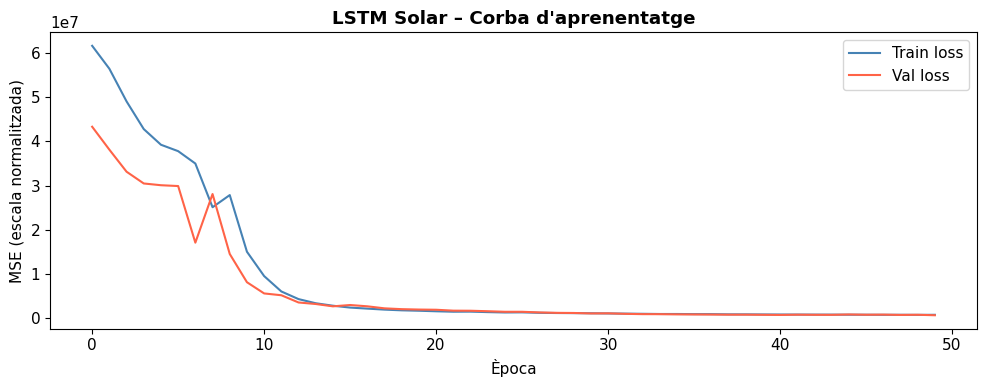

In [18]:
early_stop = keras.callbacks.EarlyStopping(
    monitor   = 'val_loss',
    patience  = PATIENCE,
    restore_best_weights = True  # recupera els pesos de la millor època
)

history_solar = model_solar.fit(
    X_seq_train_solar, y_seq_train_solar,
    validation_data = (X_seq_val_solar, y_seq_val_solar),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = [early_stop],
    verbose         = 1
)

epoques_solar = len(history_solar.history['loss'])
print(f'\nÈpoques entrenades: {epoques_solar} (early stopping a {epoques_solar - PATIENCE})')

plot_training(history_solar, 'LSTM Solar – Corba d\'aprenentatge')

### 6.5 Predicció i avaluació – Validació

--- SOLAR – Validació ---
  MAE : 405.0 MW
  RMSE: 739.8 MW
  MAPE: 51.24 %


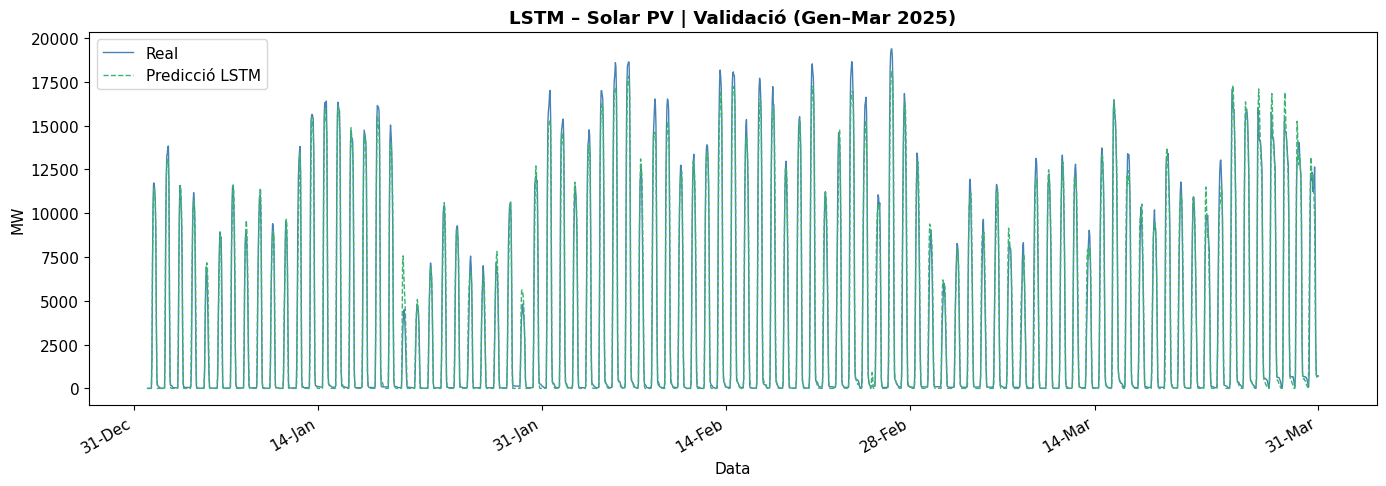

In [19]:
y_pred_val_solar = np.clip(
    model_solar.predict(X_seq_val_solar, verbose=0).flatten(), 0, None
)

metriques_val_solar = calcular_metriques(
    y_seq_val_solar, y_pred_val_solar, 'SOLAR – Validació'
)

dates_val = val.index[WINDOW_SIZE:]
plot_prediccions(
    dates  = dates_val,
    y_true = y_seq_val_solar,
    y_pred = y_pred_val_solar,
    titol  = 'LSTM – Solar PV | Validació (Gen–Mar 2025)'
)

### 6.6 Predicció i avaluació – Test (amb apagada)

--- SOLAR – Test ---
  MAE : 580.4 MW
  RMSE: 970.3 MW
  MAPE: 30.96 %


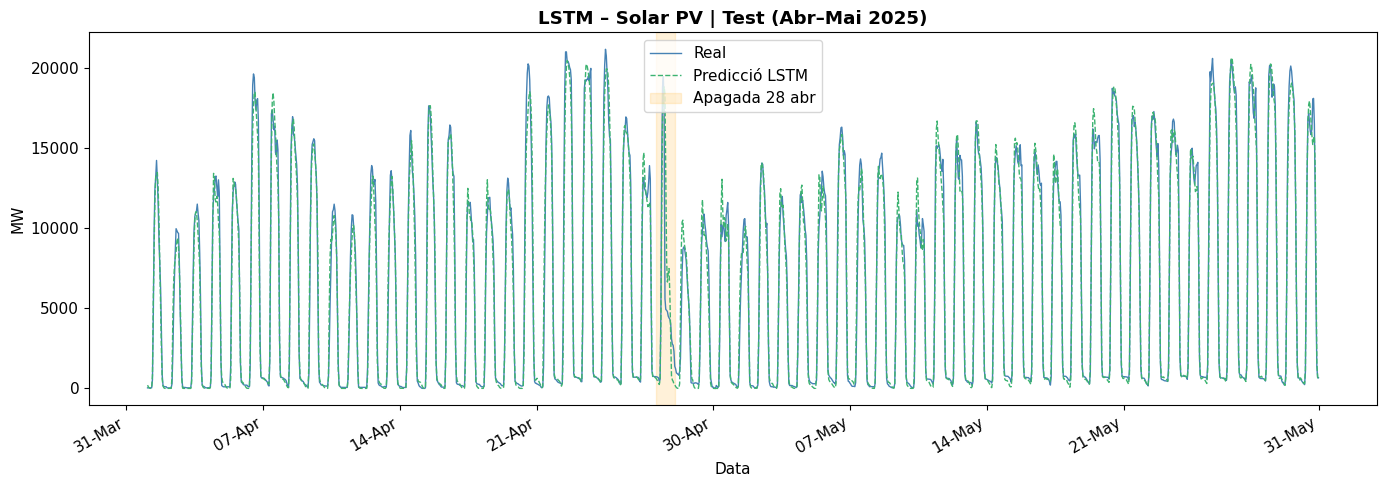

In [20]:
y_pred_test_solar = np.clip(
    model_solar.predict(X_seq_test_solar, verbose=0).flatten(), 0, None
)

metriques_test_solar = calcular_metriques(
    y_seq_test_solar, y_pred_test_solar, 'SOLAR – Test'
)

dates_test = test.index[WINDOW_SIZE:]
plot_prediccions(
    dates           = dates_test,
    y_true          = y_seq_test_solar,
    y_pred          = y_pred_test_solar,
    titol           = 'LSTM – Solar PV | Test (Abr–Mai 2025)',
    highlight_start = '2025-04-28 00:00',
    highlight_end   = '2025-04-28 23:00'
)

### 6.7 Anàlisi d'anomalies – Apagada 28 d'abril

Llindar anomalia solar: 2,136 MW
Hores anomàlies total: 66

Distribució per dia:
ds
2025-04-03    1
2025-04-05    2
2025-04-07    3
2025-04-08    1
2025-04-10    2
2025-04-11    2
2025-04-13    3
2025-04-15    1
2025-04-17    1
2025-04-19    1
2025-04-21    7
2025-04-22    2
2025-04-23    3
2025-04-24    2
2025-04-25    2
2025-04-27    1
2025-04-28    9
2025-04-29    3
2025-04-30    1
2025-05-01    1
2025-05-06    2
2025-05-08    1
2025-05-11    1
2025-05-12    2
2025-05-13    1
2025-05-17    1
2025-05-19    1
2025-05-23    1
2025-05-24    1
2025-05-25    1
2025-05-26    2
2025-05-28    2
2025-05-31    2
Name: count, dtype: int64


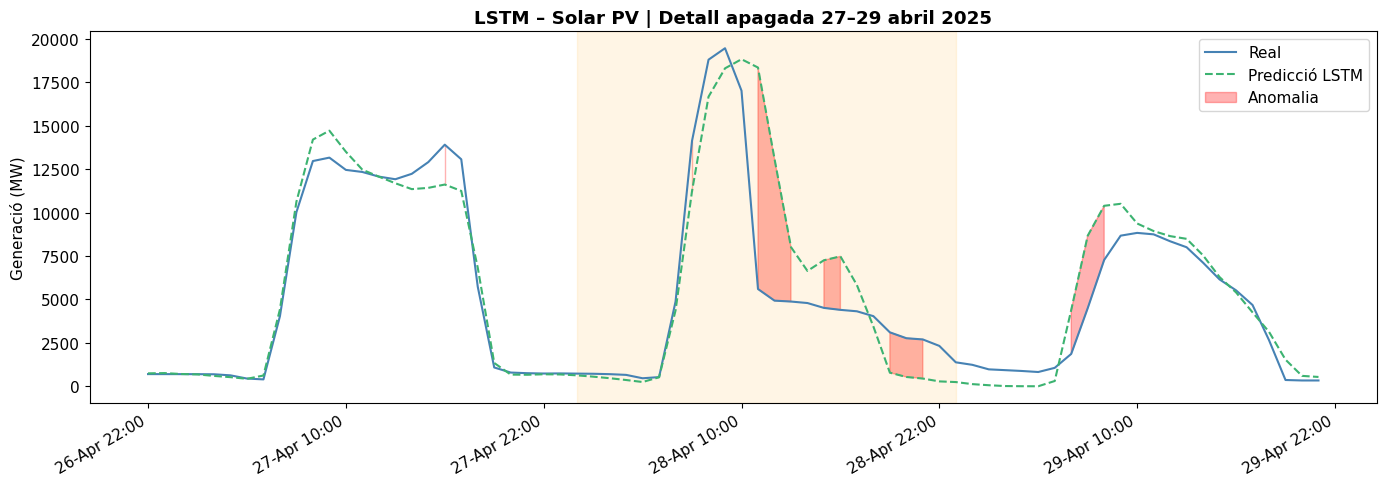

In [22]:
residus_solar = pd.DataFrame({
    'ds':     dates_test,
    'y_real': y_seq_test_solar,
    'y_pred': y_pred_test_solar,
    'residu': y_seq_test_solar - y_pred_test_solar,
})

llindar_solar = residus_solar['residu'].abs().mean() + \
                2 * residus_solar['residu'].abs().std()
residus_solar['anomalia'] = residus_solar['residu'].abs() > llindar_solar

print(f'Llindar anomalia solar: {llindar_solar:,.0f} MW')
print(f'Hores anomàlies total: {residus_solar["anomalia"].sum()}')
print()
print('Distribució per dia:')
print(residus_solar[residus_solar['anomalia']]['ds'].dt.date.value_counts().sort_index())

# Zoom 27–29 abril
mask = (residus_solar['ds'] >= '2025-04-27') & \
       (residus_solar['ds'] <= '2025-04-29 23:00')
sub = residus_solar[mask]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sub['ds'], sub['y_real'], label='Real', color='steelblue', linewidth=1.5)
ax.plot(sub['ds'], sub['y_pred'], label='Predicció LSTM', color='mediumseagreen',
        linewidth=1.5, linestyle='--')
ax.fill_between(sub['ds'], sub['y_real'], sub['y_pred'],
                where=sub['anomalia'], alpha=0.3, color='red', label='Anomalia')
ax.axvspan(pd.Timestamp('2025-04-28 00:00'), pd.Timestamp('2025-04-28 23:00'),
           alpha=0.1, color='orange')
ax.set_title('LSTM – Solar PV | Detall apagada 27–29 abril 2025', fontweight='bold')
ax.set_ylabel('Generació (MW)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('lstm_solar_detall_apagada.pdf', bbox_inches='tight')
plt.show()

---
## 7. MODEL B: Eòlica
### 7.1 Normalització

In [23]:
scaler_eolic = MinMaxScaler()

X_train_eolic_raw = train[FEATURES_EOLIC].values
X_val_eolic_raw   = val[FEATURES_EOLIC].values
X_test_eolic_raw  = test[FEATURES_EOLIC].values

X_train_eolic_norm = scaler_eolic.fit_transform(X_train_eolic_raw)
X_val_eolic_norm   = scaler_eolic.transform(X_val_eolic_raw)
X_test_eolic_norm  = scaler_eolic.transform(X_test_eolic_raw)

y_train_eolic = train[TARGET_EOLIC].values
y_val_eolic   = val[TARGET_EOLIC].values
y_test_eolic  = test[TARGET_EOLIC].values

print(f'Scaler eòlica entrenat amb {len(X_train_eolic_raw):,} registres.')

Scaler eòlica entrenat amb 17,377 registres.


### 7.2 Creació de seqüències

In [35]:
# Seqüències de train
X_seq_train_eolic, y_seq_train_eolic = crear_sequences(
    X_train_eolic_norm, y_train_eolic, WINDOW_SIZE
)

# Seqüències de val: necessitem les últimes W hores del train com a context
X_trainval_eolic_norm = np.concatenate([X_train_eolic_norm, X_val_eolic_norm])
y_trainval_eolic      = np.concatenate([y_train_eolic, y_val_eolic])
X_seq_all_eolic, y_seq_all_eolic = crear_sequences(
    X_trainval_eolic_norm, y_trainval_eolic, WINDOW_SIZE
)
X_seq_val_eolic = X_seq_all_eolic[len(X_seq_train_eolic):]
y_seq_val_eolic = y_seq_all_eolic[len(X_seq_train_eolic):]  # ← X, no y

# Retallar val a la mida correcta
X_seq_val_eolic = X_seq_val_eolic[:len(val) - WINDOW_SIZE]
y_seq_val_eolic = y_seq_val_eolic[:len(val) - WINDOW_SIZE]

# Seqüències de test: necessitem les últimes W hores del val com a context
X_valtest_eolic_norm = np.concatenate([X_val_eolic_norm, X_test_eolic_norm])
y_valtest_eolic      = np.concatenate([y_val_eolic, y_test_eolic])
X_seq_all_test_eolic, y_seq_all_test_eolic = crear_sequences(
    X_valtest_eolic_norm, y_valtest_eolic, WINDOW_SIZE
)
X_seq_test_eolic = X_seq_all_test_eolic[len(X_seq_val_eolic):]
y_seq_test_eolic = y_seq_all_test_eolic[len(X_seq_val_eolic):]  # ← X, no y

# Retallar test a la mida correcta
X_seq_test_eolic = X_seq_test_eolic[:len(test) - WINDOW_SIZE]
y_seq_test_eolic = y_seq_test_eolic[:len(test) - WINDOW_SIZE]

print(f'Train sequences: {X_seq_train_eolic.shape}')
print(f'Val   sequences: {X_seq_val_eolic.shape}')
print(f'Test  sequences: {X_seq_test_eolic.shape}')
print(f'Coincideix val:  {len(val.index[WINDOW_SIZE:])}')
print(f'Coincideix test: {len(test.index[WINDOW_SIZE:])}')

Train sequences: (17353, 24, 12)
Val   sequences: (2137, 24, 12)
Test  sequences: (1438, 24, 12)
Coincideix val:  2137
Coincideix test: 1438


### 7.3 Arquitectura i entrenament

Epoch 1/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 61965756.0000 - val_loss: 79295936.0000
Epoch 2/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 56202840.0000 - val_loss: 69787184.0000
Epoch 3/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 47052012.0000 - val_loss: 57227336.0000
Epoch 4/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 36873912.0000 - val_loss: 44459072.0000
Epoch 5/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 28020558.0000 - val_loss: 33784812.0000
Epoch 6/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 21877556.0000 - val_loss: 26327098.0000
Epoch 7/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 18475930.0000 - val_loss: 21958038.0000
Epoch 8/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 17058178.0000 - val_loss: 19786360.0000
Epoch 9/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 14550744.0000 - val_loss: 15093791.0000
Epoch 10/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 8981640.0000 - val_loss: 9845001.0000
E

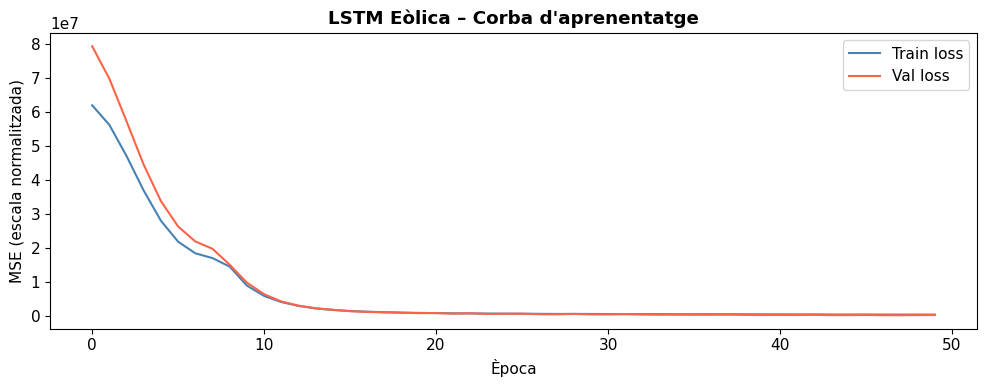

In [36]:
model_eolic = construir_model(
    input_shape=(WINDOW_SIZE, X_seq_train_eolic.shape[2]),
    lstm_units=LSTM_UNITS,
    dropout=DROPOUT
)

early_stop_eolic = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True
)

history_eolic = model_eolic.fit(
    X_seq_train_eolic, y_seq_train_eolic,
    validation_data = (X_seq_val_eolic, y_seq_val_eolic),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = [early_stop_eolic],
    verbose         = 1
)

epoques_eolic = len(history_eolic.history['loss'])
print(f'\nÈpoques entrenades: {epoques_eolic}')

plot_training(history_eolic, 'LSTM Eòlica – Corba d\'aprenentatge')

### 7.4 Predicció i avaluació – Validació

--- EÒLICA – Validació ---
  MAE : 374.7 MW
  RMSE: 518.2 MW
  MAPE: 5.41 %


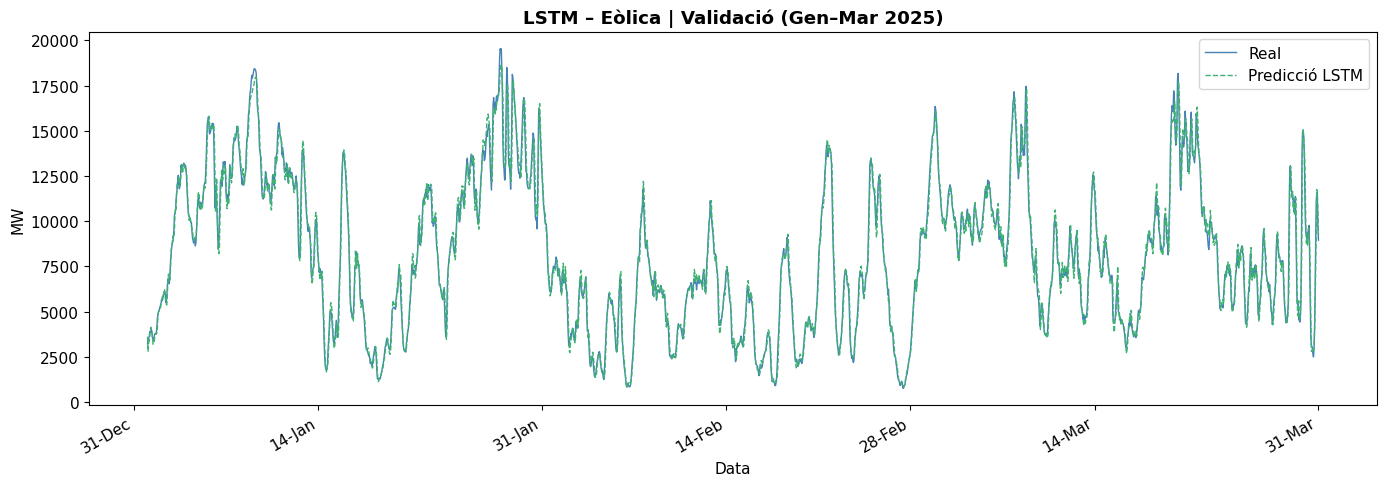

In [37]:
y_pred_val_eolic = np.clip(
    model_eolic.predict(X_seq_val_eolic, verbose=0).flatten(), 0, None
)

metriques_val_eolic = calcular_metriques(
    y_seq_val_eolic, y_pred_val_eolic, 'EÒLICA – Validació'
)

plot_prediccions(
    dates  = val.index[WINDOW_SIZE:],
    y_true = y_seq_val_eolic,
    y_pred = y_pred_val_eolic,
    titol  = 'LSTM – Eòlica | Validació (Gen–Mar 2025)'
)

### 7.5 Predicció i avaluació – Test

--- EÒLICA – Test ---
  MAE : 349.7 MW
  RMSE: 480.8 MW
  MAPE: 8.68 %


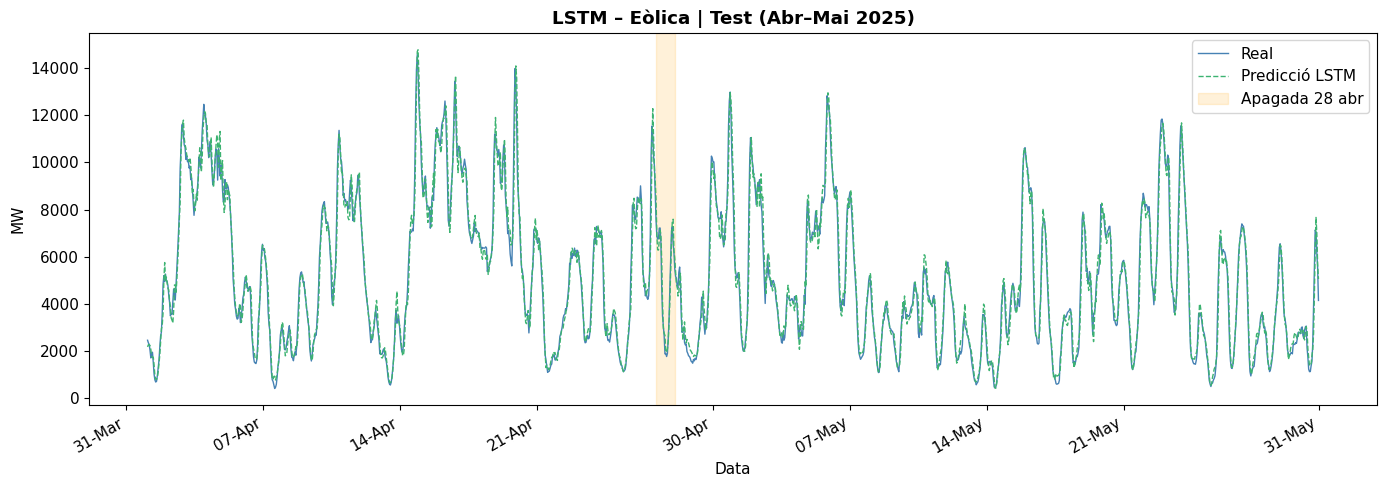

In [38]:
y_pred_test_eolic = np.clip(
    model_eolic.predict(X_seq_test_eolic, verbose=0).flatten(), 0, None
)

metriques_test_eolic = calcular_metriques(
    y_seq_test_eolic, y_pred_test_eolic, 'EÒLICA – Test'
)

plot_prediccions(
    dates           = test.index[WINDOW_SIZE:],
    y_true          = y_seq_test_eolic,
    y_pred          = y_pred_test_eolic,
    titol           = 'LSTM – Eòlica | Test (Abr–Mai 2025)',
    highlight_start = '2025-04-28 00:00',
    highlight_end   = '2025-04-28 23:00'
)

### 7.6 Anàlisi d'anomalies – Apagada 28 d'abril

Llindar anomalia eòlica: 1,010 MW
Hores anomàlies total: 73

Distribució per dia:
ds
2025-04-02    1
2025-04-03    1
2025-04-04    1
2025-04-05    3
2025-04-06    1
2025-04-11    3
2025-04-12    1
2025-04-14    1
2025-04-15    4
2025-04-16    3
2025-04-17    4
2025-04-19    1
2025-04-20    7
2025-04-21    1
2025-04-25    1
2025-04-26    2
2025-04-27    3
2025-04-28    2
2025-04-30    3
2025-05-01    2
2025-05-02    4
2025-05-03    4
2025-05-05    2
2025-05-06    1
2025-05-07    1
2025-05-11    2
2025-05-12    1
2025-05-16    1
2025-05-17    1
2025-05-19    1
2025-05-20    2
2025-05-21    1
2025-05-22    1
2025-05-23    1
2025-05-24    2
2025-05-26    1
2025-05-31    2
Name: count, dtype: int64


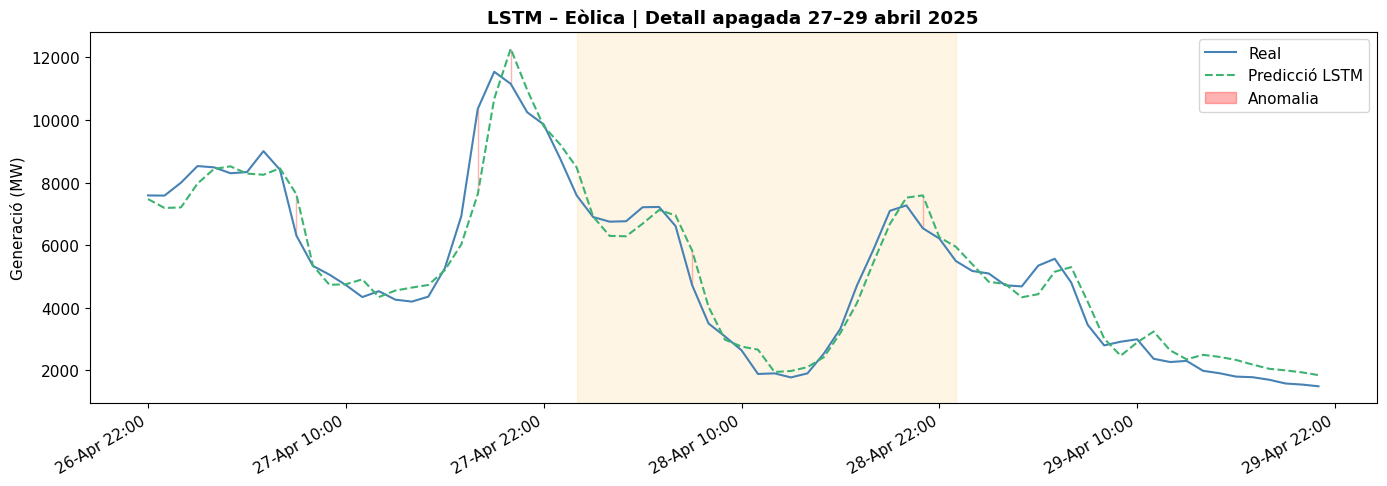

In [39]:
residus_eolic = pd.DataFrame({
    'ds':     test.index[WINDOW_SIZE:],
    'y_real': y_seq_test_eolic,
    'y_pred': y_pred_test_eolic,
    'residu': y_seq_test_eolic - y_pred_test_eolic,
})

llindar_eolic = residus_eolic['residu'].abs().mean() + \
                2 * residus_eolic['residu'].abs().std()
residus_eolic['anomalia'] = residus_eolic['residu'].abs() > llindar_eolic

print(f'Llindar anomalia eòlica: {llindar_eolic:,.0f} MW')
print(f'Hores anomàlies total: {residus_eolic["anomalia"].sum()}')
print()
print('Distribució per dia:')
print(residus_eolic[residus_eolic['anomalia']]['ds'].dt.date.value_counts().sort_index())

# Zoom 27–29 abril
mask_e = (residus_eolic['ds'] >= '2025-04-27') & \
         (residus_eolic['ds'] <= '2025-04-29 23:00')
sub_e = residus_eolic[mask_e]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sub_e['ds'], sub_e['y_real'], label='Real', color='steelblue', linewidth=1.5)
ax.plot(sub_e['ds'], sub_e['y_pred'], label='Predicció LSTM', color='mediumseagreen',
        linewidth=1.5, linestyle='--')
ax.fill_between(sub_e['ds'], sub_e['y_real'], sub_e['y_pred'],
                where=sub_e['anomalia'], alpha=0.3, color='red', label='Anomalia')
ax.axvspan(pd.Timestamp('2025-04-28 00:00'), pd.Timestamp('2025-04-28 23:00'),
           alpha=0.1, color='orange')
ax.set_title('LSTM – Eòlica | Detall apagada 27–29 abril 2025', fontweight='bold')
ax.set_ylabel('Generació (MW)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('lstm_eolic_detall_apagada.pdf', bbox_inches='tight')
plt.show()

---
## 8. Baseline naïf (persistència)

Referència mínima: y_pred(t) = y_real(t-1).
Nota: les seqüències perden les primeres WINDOW_SIZE hores,
per tant el baseline es calcula sobre el mateix subconjunt.

In [44]:
# Índex del target dins les features
idx_solar = FEATURES_SOLAR.index(TARGET_SOLAR)
idx_eolic = FEATURES_EOLIC.index(TARGET_EOLIC)

# Desnormalitzar: agafem l'últim pas de la finestra i desnormalitzem
def desnormalitzar_col(X_seq, scaler, idx_col):
    """Extreu i desnormalitza una columna de les seqüències X."""
    vals_norm = X_seq[:, -1, idx_col].reshape(-1, 1)
    # Creem un array de zeros de la mida del scaler i posem els valors a la columna correcta
    dummy = np.zeros((len(vals_norm), scaler.n_features_in_))
    dummy[:, idx_col] = vals_norm[:, 0]
    return scaler.inverse_transform(dummy)[:, idx_col]

y_naive_val_solar  = desnormalitzar_col(X_seq_val_solar,  scaler_solar, idx_solar)
y_naive_test_solar = desnormalitzar_col(X_seq_test_solar, scaler_solar, idx_solar)
y_naive_val_eolic  = desnormalitzar_col(X_seq_val_eolic,  scaler_eolic, idx_eolic)
y_naive_test_eolic = desnormalitzar_col(X_seq_test_eolic, scaler_eolic, idx_eolic)

print('=== BASELINE NAÏF (persistència) ===')
naive_val_solar  = calcular_metriques(y_seq_val_solar,  y_naive_val_solar,  'SOLAR Naïf – Validació')
naive_test_solar = calcular_metriques(y_seq_test_solar, y_naive_test_solar, 'SOLAR Naïf – Test')
naive_val_eolic  = calcular_metriques(y_seq_val_eolic,  y_naive_val_eolic,  'EÒLICA Naïf – Validació')
naive_test_eolic = calcular_metriques(y_seq_test_eolic, y_naive_test_eolic, 'EÒLICA Naïf – Test')

=== BASELINE NAÏF (persistència) ===
--- SOLAR Naïf – Validació ---
  MAE : 1,066.6 MW
  RMSE: 2,015.3 MW
  MAPE: 68.89 %
--- SOLAR Naïf – Test ---
  MAE : 1,297.1 MW
  RMSE: 2,333.2 MW
  MAPE: 46.15 %
--- EÒLICA Naïf – Validació ---
  MAE : 405.2 MW
  RMSE: 575.0 MW
  MAPE: 5.90 %
--- EÒLICA Naïf – Test ---
  MAE : 443.4 MW
  RMSE: 622.4 MW
  MAPE: 10.67 %


---
## 9. Resum de mètriques

In [45]:
resum = pd.DataFrame({
    'Model / Conjunt': [
        'LSTM Solar – Validació',
        'LSTM Solar – Test',
        'LSTM Eòlica – Validació',
        'LSTM Eòlica – Test',
        'Naïf Solar – Validació',
        'Naïf Solar – Test',
        'Naïf Eòlica – Validació',
        'Naïf Eòlica – Test',
    ],
    'MAE (MW)': [
        round(metriques_val_solar['MAE'],  1),
        round(metriques_test_solar['MAE'], 1),
        round(metriques_val_eolic['MAE'],  1),
        round(metriques_test_eolic['MAE'], 1),
        round(naive_val_solar['MAE'],  1),
        round(naive_test_solar['MAE'], 1),
        round(naive_val_eolic['MAE'],  1),
        round(naive_test_eolic['MAE'], 1),
    ],
    'RMSE (MW)': [
        round(metriques_val_solar['RMSE'],  1),
        round(metriques_test_solar['RMSE'], 1),
        round(metriques_val_eolic['RMSE'],  1),
        round(metriques_test_eolic['RMSE'], 1),
        round(naive_val_solar['RMSE'],  1),
        round(naive_test_solar['RMSE'], 1),
        round(naive_val_eolic['RMSE'],  1),
        round(naive_test_eolic['RMSE'], 1),
    ],
})

print('\n=== RESUM MÈTRIQUES LSTM ===')
print(resum.to_string(index=False))

resum.to_csv('metriques_lstm.csv', index=False)
print('\nDades desades a metriques_lstm.csv')


=== RESUM MÈTRIQUES LSTM ===
        Model / Conjunt  MAE (MW)  RMSE (MW)
 LSTM Solar – Validació     405.0      739.8
      LSTM Solar – Test     580.4      970.3
LSTM Eòlica – Validació     374.7      518.2
     LSTM Eòlica – Test     349.7      480.8
 Naïf Solar – Validació    1066.6     2015.3
      Naïf Solar – Test    1297.1     2333.2
Naïf Eòlica – Validació     405.2      575.0
     Naïf Eòlica – Test     443.4      622.4

Dades desades a metriques_lstm.csv


---
## 10. Desar models

In [46]:
model_solar.save('lstm_solar.keras')
model_eolic.save('lstm_eolic.keras')
print('Models desats: lstm_solar.keras i lstm_eolic.keras')

Models desats: lstm_solar.keras i lstm_eolic.keras
